<a href="https://colab.research.google.com/github/Nandaodevmax/predictive-maintenance-project/blob/main/Data_Science_Aplicadp_Manutencao_Preditiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

dados = {
    "temperatura": np.random.randint(50, 100, 100),
    "vibracao": np.random.uniform(0.1, 1.0, 100),
    "pressao": np.random.randint(20, 50, 100),
    "horas_operacao": np.random.randint(100, 500, 100),
}

df = pd.DataFrame(dados)

#lógica de falha
df["falha"] = (
    (df["temperatura"] > 80) &
    (df["vibracao"] > 0.6)
).astype(int)

df.head()

,temperatura,vibracao,pressao,horas_operacao,falha
0,88,0.481061,47,474,0
1,78,0.455393,46,121,0
2,64,0.364139,23,337,0
3,92,0.112672,38,257,0
4,57,0.278958,45,137,0


In [2]:
print(df["falha"].value_counts())

falha
0    84
1    16
Name: count, dtype: int64


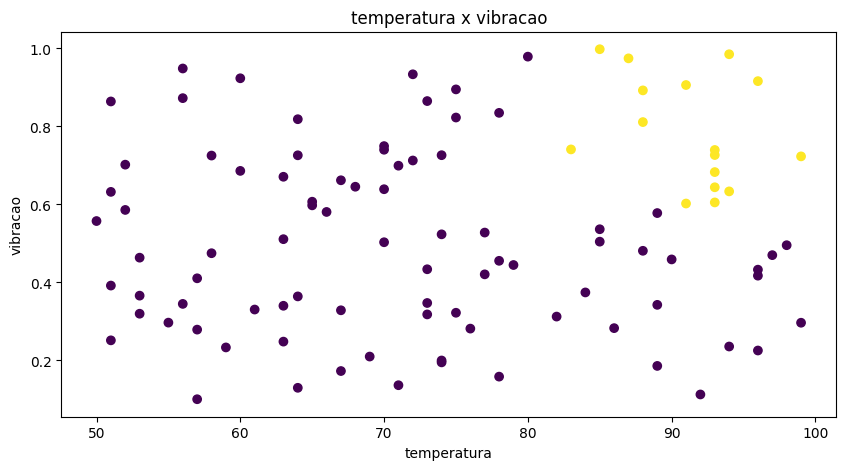

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.scatter(df["temperatura"], df["vibracao"], c=df["falha"])

plt.xlabel("temperatura")
plt.ylabel("vibracao")
plt.title("temperatura x vibracao")

plt.show()


In [4]:
#Criar algoritmo de Machine Learning Profissional
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# entradas
X = df[["temperatura", "vibracao", "pressao", "horas_operacao"]]

# saídas
y = df["falha"]

# divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# modelo
modelo = DecisionTreeClassifier()

# treinamento
modelo.fit(X_train, y_train)

#previsoes
previsoes = modelo.predict(X_test)

# acurácia
acuracia = accuracy_score(y_test, previsoes)

print("Acurácia", acuracia)

Acurácia 0.9333333333333333


In [ ]:
# Explicação importante
# train_test_split
# Divide os dados: treino, teste


# accuracy_score
# mede: Quantas previsões o modelo acertou

In [ ]:
# Matriz de Confusão
# Ela mostra: acertos, erros, falso positivo, falso negativo
# Muito usado em entrevista

In [5]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

matriz = confusion_matrix(y_test, previsoes)
print(matriz)

[[23  1]
 [ 1  5]]


In [ ]:
# 23 acertou normais
# 1 achou falhas mas não era
# 1 deixou falha passar
# 5 acertou falha

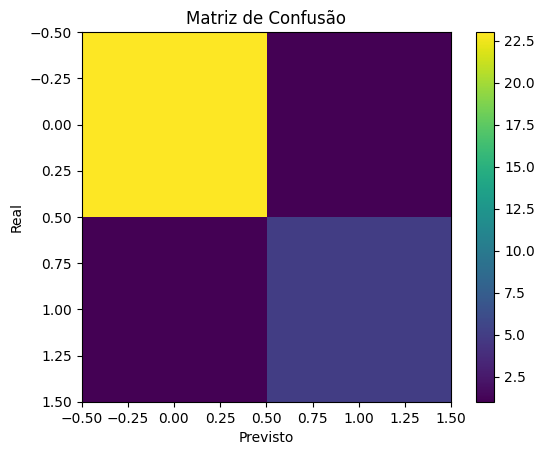

In [7]:
# vamos desenhar a matrix
plt.imshow(matriz)
plt.title("Matriz de Confusão")
plt.colorbar()

plt.xlabel("Previsto")
plt.ylabel("Real")

plt.show()

In [11]:
# Feature importance: Qual variável mais influencia a falha

import pandas as pd
importancias = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": modelo.feature_importances_
})

print(importancias.sort_values(by="Importancia", ascending=False))

         Variavel  Importancia
1        vibracao     0.611111
0     temperatura     0.388889
2         pressao     0.000000
3  horas_operacao     0.000000


In [ ]:
# A Vibracão foi a variável com maior influência na previsao de falhas

In [4]:
import pandas as pd

dados = {
    "tempo":[1, 2, 3, 4, 5, 6, 7, 8],
    "temperatura":[65, 70, 75, 80, 60, 85, 90, 55],
    "vibracao":[0.2, 0.3, 0.4, 0.6, 0.2, 0.7, 0.8, 0.1],
    "pressao":[30, 32, 35, 40, 28, 42, 45, 25],
    "horas_operacao":[120, 130, 140, 150, 110, 160, 170, 100],
    "falha":[0, 0, 0, 1, 0, 1, 1, 0]
}

df = pd.DataFrame(dados)
df.to_csv("manutencao_profissional.csv", index=False)

In [5]:
# Criar Dashboard de Manutenção Preditiva
# Nosso Dashboard terá:
# Total de falhas
# Temperatura média
# Vbração média
# Equipamentos críticos
# Gráficos de tendência
# Indicadores industriais

df.to_csv("manutencao_profissional.csv", index=False)

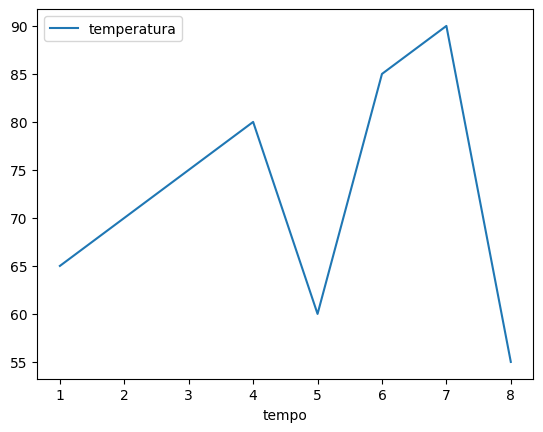

In [7]:
import matplotlib.pyplot as plt
df.plot(x="tempo", y="temperatura", kind="line")
plt.show()

In [ ]:
# Ánalise do gráfico de temperatura
# O que está acontecendo:
# A temperatura começa 65
# Sobe gradualmente até 80(tempo 4)
# Cai (tempo 5)
# Depois dispara pra 85 e 90 (tempos 6 e 7)
# E depois despenca (tempo 8)
# EQUIPAMENTO TENDE A FALHAR QUANDO OPERAM SOB TEMPERATURA ELEVADA OU APÓS AUMENTO RÁPIDO DE TEMPERATURA.

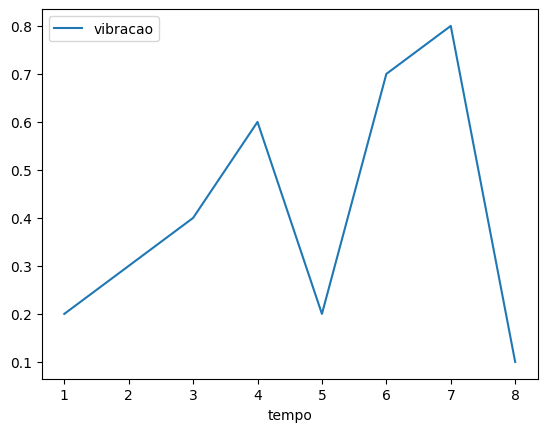

In [8]:
df.plot(x="tempo", y="vibracao", kind="line")
plt.show()

In [ ]:
# Análise da Vibração
# O que da pra ver:
# Começa baixa (0.2)
# Sobe gradualmente até 0.6(tempo 4)
# Cai (tempo 5)
# Depois sobe forte pra 0.7 e 0.8 (tempos 6 e 7)
# Depois despenca (tempo 8)
# Falhas ocorreram nos tempos 4, 6 e 7
# Antes da falha: Vibração está alta ou em crescimento nos tempos 6 e 7, está no pico
# O aumento da vibração está diretamente relacionado à ocorrência de falhas, sendo um forte indicador preditivo de problemas no equipamento.
# Classico de manutenção industrial real: Desalinhamento, folga mecânica, desgaste.

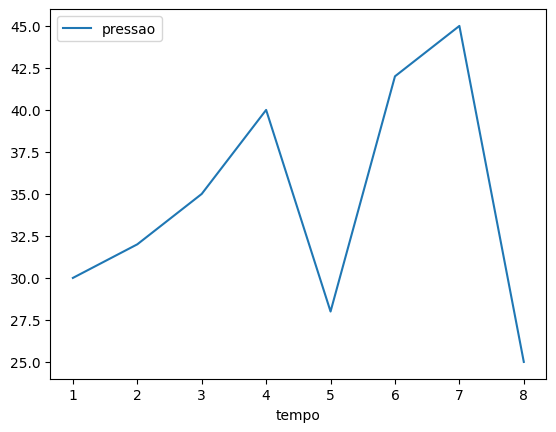

In [9]:
df.plot(x="tempo", y="pressao", kind="line")
plt.show()

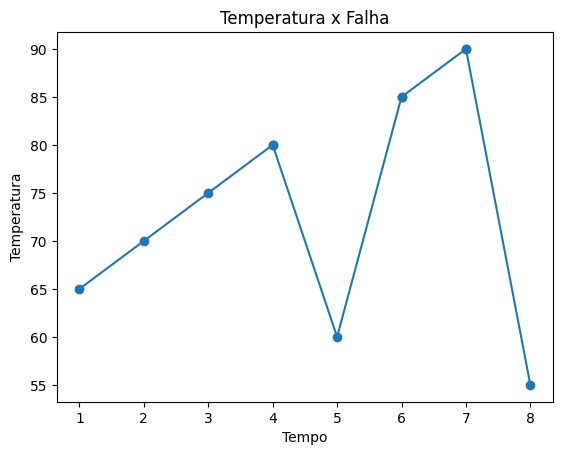

In [10]:
import matplotlib.pyplot as plt
plt.plot(df["tempo"], df["temperatura"], marker='o')

# Marcar falhas
falhas = df[df["falha"]== 1]
plt.scatter(falhas["tempo"], falhas["temperatura"])

plt.xlabel("Tempo")
plt.ylabel("Temperatura")
plt.title("Temperatura x Falha")

plt.show()

In [ ]:
# Pontos destacados exatamente onde houve falha
# Visualmente claro que:
# Falhas acontecem em temperaturas mais altas
# ÁNALISE DE COMPORTAMENTO, IDENTIFICAÇÃO DE PADRÃO, CORRELAÇÃO COM FALHA

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Variaveis de (entrada)
X = df[["temperatura", "vibracao", "pressao"]]

# Target (saída)
y = df["falha"]

# dividir treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

# modelo
modelo = DecisionTreeClassifier()
modelo.fit(X_train, y_train)

# previsão
previsoes = modelo.predict(X_test)

print(previsoes)
print(y_test.values)

[0 0 0 1]
[0 0 0 1]


In [16]:
print(df["falha"].value_counts())

falha
0    5
1    3
Name: count, dtype: int64


In [18]:
novo_dado = [[88, 0.75, 44]] # temperatura, vibração, pressão
previsao = modelo.predict(novo_dado)
print(previsao)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [19]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, previsoes))

1.0
